# Day 15 – End-to-End Trading Research System (EURUSD)

## Objective
Build a complete trading research pipeline that combines feature engineering, prediction, risk management, and performance evaluation.

## Goal
Create a full capstone project that demonstrates an end-to-end quantitative workflow.

In [1]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [2]:
#Create Output Folders
os.makedirs("outputs/charts", exist_ok=True)
os.makedirs("outputs/tables", exist_ok=True)

In [3]:
#Load Base Dataset
file_path = r"C:\Users\THIS PC\Desktop\quant-finance-portfolio\day-01-market-data-analysis\data\eurusd_daily_raw.csv"
df = pd.read_csv(file_path, index_col=0)

df.index = pd.to_datetime(df.index)
df = df.sort_index()

df.head()

,open,high,low,close,simple_return,log_return,cum_return,equity_curve,rolling_peak,drawdown
2007-01-17,1.2917,1.2950,1.2898,1.2938,NaN,NaN,NaN,NaN,NaN,NaN
2007-01-18,1.2938,1.2976,1.2896,1.2963,0.001932,0.001930,0.001932,1.001932,1.001932,0.000000
2007-01-19,1.2963,1.3001,1.2914,1.2961,-0.000154,-0.000154,0.001778,1.001778,1.001932,-0.000154
2007-01-22,1.2959,1.2977,1.2923,1.2949,-0.000926,-0.000926,0.000850,1.000850,1.001932,-0.001080
2007-01-23,1.2949,1.3044,1.2929,1.3026,0.005946,0.005929,0.006802,1.006802,1.006802,0.000000


In [4]:
#Rebuild Core Return Series
if "simple_return" not in df.columns:
    df["simple_return"] = df["close"].pct_change()

In [6]:
#Feature Engineering
#Lagged returns
df["return_lag_1"] = df["simple_return"].shift(1)
df["return_lag_2"] = df["simple_return"].shift(2)
df["return_lag_3"] = df["simple_return"].shift(3)

In [7]:
#Rolling features
df["rolling_mean_5"] = df["simple_return"].rolling(5).mean()
df["rolling_std_5"] = df["simple_return"].rolling(5).std()

In [8]:
#Momentum
df["momentum_5"] = df["close"] / df["close"].shift(5) - 1
df["momentum_10"] = df["close"] / df["close"].shift(10) - 1

In [9]:
#Range features
df["high_low_range"] = (df["high"] - df["low"]) / df["close"]
df["open_close_range"] = (df["close"] - df["open"]) / df["open"]

In [10]:
#Technical Features
#SMA ratio
df["SMA_10"] = df["close"].rolling(10).mean()
df["SMA_20"] = df["close"].rolling(20).mean()
df["SMA_ratio"] = df["SMA_10"] / df["SMA_20"]

In [11]:
#RSI
delta = df["close"].diff()
gain = delta.where(delta > 0, 0)
loss = -delta.where(delta < 0, 0)

avg_gain = gain.rolling(14).mean()
avg_loss = loss.rolling(14).mean()

rs = avg_gain / avg_loss
df["RSI_14"] = 100 - (100 / (1 + rs))

In [12]:
#MACD
df["EMA_12"] = df["close"].ewm(span=12, adjust=False).mean()
df["EMA_26"] = df["close"].ewm(span=26, adjust=False).mean()
df["MACD"] = df["EMA_12"] - df["EMA_26"]

In [13]:
#Create Prediction Target
df["target"] = np.where(df["simple_return"].shift(-1) > 0, 1, 0)

In [14]:
#Build Modeling Dataset
feature_cols = [
    "return_lag_1", "return_lag_2", "return_lag_3",
    "rolling_mean_5", "rolling_std_5",
    "momentum_5", "momentum_10",
    "high_low_range", "open_close_range",
    "SMA_ratio", "RSI_14", "MACD"
]

model_df = df[feature_cols + ["target", "simple_return"]].dropna().copy()
model_df.head()

,return_lag_1,return_lag_2,return_lag_3,rolling_mean_5,rolling_std_5,momentum_5,momentum_10,high_low_range,open_close_range,SMA_ratio,RSI_14,MACD,target,simple_return
2007-02-13,-0.002999,-0.002684,0.002152,0.000836,0.003616,0.004159,0.005243,0.006827,0.005476,1.001568,56.261682,0.001660,1,0.005476
2007-02-14,0.005476,-0.002999,-0.002684,0.001800,0.004594,0.008992,0.007366,0.009521,0.006980,1.001571,66.836735,0.002625,1,0.007057
2007-02-15,0.007057,0.005476,-0.002999,0.001538,0.004606,0.007669,0.009139,0.004033,0.000838,1.001804,69.296741,0.003439,0,0.000838
2007-02-16,0.000838,0.007057,0.005476,0.002029,0.004152,0.010150,0.013579,0.003958,-0.000228,1.002480,66.544118,0.004014,1,-0.000228
2007-02-19,-0.000228,0.000838,0.007057,0.002902,0.003174,0.014577,0.017559,0.003117,0.000685,1.003430,66.909091,0.004562,0,0.001370


In [15]:
#Train/Test Split
split_index = int(len(model_df) * 0.7)

train = model_df.iloc[:split_index].copy()
test = model_df.iloc[split_index:].copy()

X_train = train[feature_cols]
y_train = train["target"]

X_test = test[feature_cols]
y_test = test["target"]

In [16]:
#Train Predictive Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [18]:
#Make Predictions
test["prediction"] = model.predict(X_test)

In [19]:
#Translate Predictions into Trading Rule
'''Rule:
predict up → long
predict down → flat'''
test["position"] = test["prediction"]

In [20]:
#Add Volatility-Based Position Sizing
#First compute rolling volatility from returns:

test["rolling_vol"] = test["simple_return"].rolling(20).std()

#Set a target volatility:

target_vol = 0.01
test["position_size"] = target_vol / test["rolling_vol"]
test["position_size"] = test["position_size"].clip(upper=3)

In [21]:
#Add Transaction Cost

#Detect trades:

test["trade"] = test["position"].diff().abs().fillna(0)
transaction_cost = 0.0002

#Compute strategy returns:

test["strategy_return"] = (
    test["position"] * test["simple_return"] * test["position_size"]
    - test["trade"] * transaction_cost
)

In [22]:
#Build Equity Curve
test["strategy_equity"] = (1 + test["strategy_return"]).cumprod()
test["buy_hold"] = (1 + test["simple_return"]).cumprod()

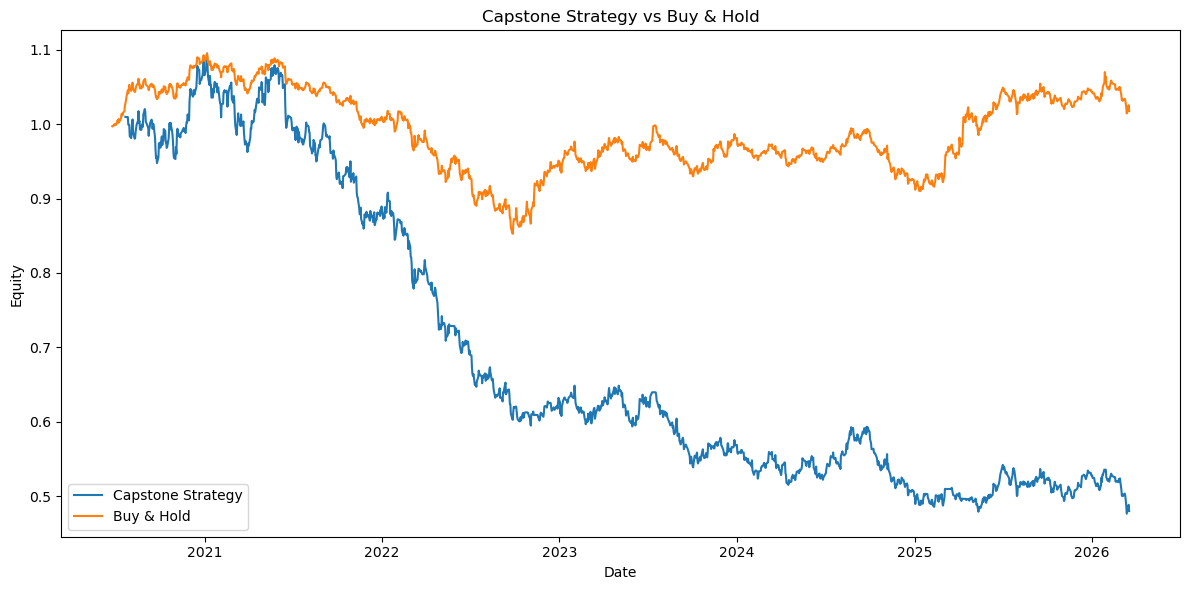

In [23]:
#Plot Performance
plt.figure(figsize=(12, 6))

plt.plot(test.index, test["strategy_equity"], label="Capstone Strategy")
plt.plot(test.index, test["buy_hold"], label="Buy & Hold")

plt.title("Capstone Strategy vs Buy & Hold")
plt.xlabel("Date")
plt.ylabel("Equity")
plt.legend()

plt.tight_layout()
plt.savefig("outputs/charts/day15_capstone_equity.png")
plt.show()

In [24]:
#Drawdown
rolling_max = test["strategy_equity"].cummax()
test["drawdown"] = (test["strategy_equity"] - rolling_max) / rolling_max

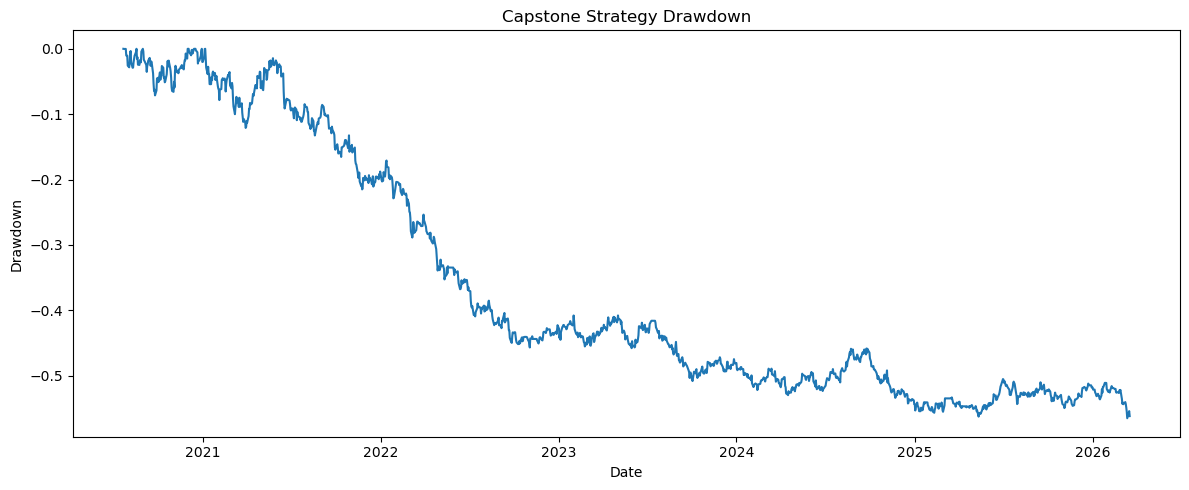

In [25]:
#Plot:
plt.figure(figsize=(12, 5))
plt.plot(test.index, test["drawdown"])

plt.title("Capstone Strategy Drawdown")
plt.xlabel("Date")
plt.ylabel("Drawdown")

plt.tight_layout()
plt.savefig("outputs/charts/day15_capstone_drawdown.png")
plt.show()

In [26]:
#Model Metrics
accuracy = accuracy_score(y_test, test["prediction"])
print("Accuracy:", accuracy)
print(classification_report(y_test, test["prediction"]))

Accuracy: 0.5023411371237458
              precision    recall  f1-score   support

           0       0.60      0.05      0.10       757
           1       0.50      0.96      0.66       738

    accuracy                           0.50      1495
   macro avg       0.55      0.51      0.38      1495
weighted avg       0.55      0.50      0.37      1495



In [27]:
#Strategy Metrics
total_return = test["strategy_equity"].iloc[-1] - 1
annual_return = test["strategy_return"].mean() * 252
annual_vol = test["strategy_return"].std() * np.sqrt(252)
sharpe = annual_return / annual_vol if annual_vol != 0 else np.nan
max_dd = test["drawdown"].min()

capstone_metrics = pd.DataFrame({
    "Metric": [
        "Prediction Accuracy",
        "Total Return",
        "Annual Return",
        "Annual Volatility",
        "Sharpe Ratio",
        "Max Drawdown"
    ],
    "Value": [
        accuracy,
        total_return,
        annual_return,
        annual_vol,
        sharpe,
        max_dd
    ]
})

capstone_metrics

,Metric,Value
0,Prediction Accuracy,0.502341
1,Total Return,-0.519995
2,Annual Return,-0.114490
3,Annual Volatility,0.146852
4,Sharpe Ratio,-0.779634
5,Max Drawdown,-0.564938


In [28]:
#Feature Coefficients
coef_df = pd.DataFrame({
    "Feature": feature_cols,
    "Coefficient": model.coef_[0]
}).sort_values(by="Coefficient", ascending=False)

coef_df

,Feature,Coefficient
11,MACD,0.108113
9,SMA_ratio,0.030786
10,RSI_14,0.000495
4,rolling_std_5,-0.016810
2,return_lag_3,-0.030053
3,rolling_mean_5,-0.141254
0,return_lag_1,-0.157967
7,high_low_range,-0.194629
1,return_lag_2,-0.198378
8,open_close_range,-0.286400


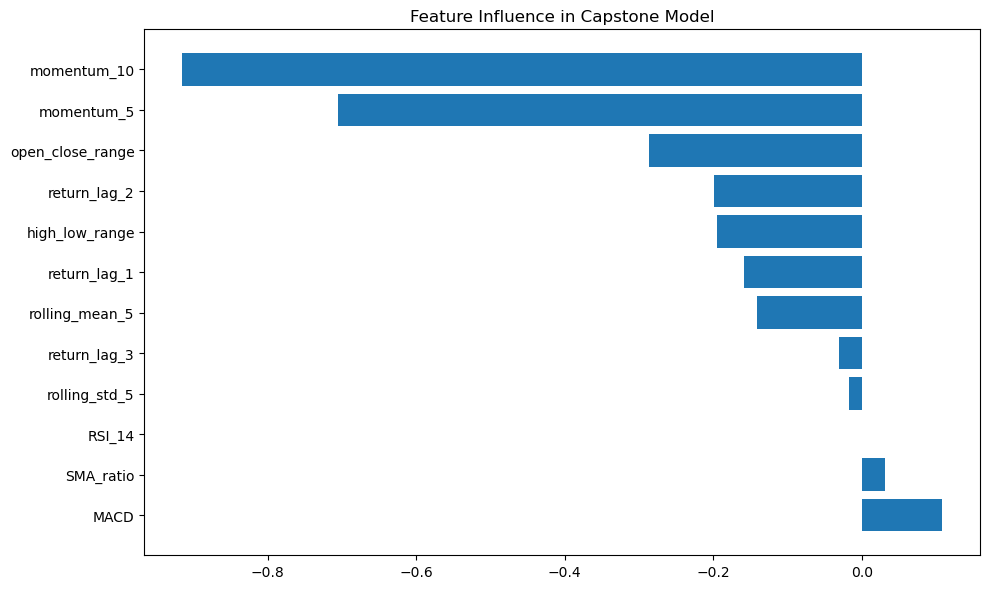

In [29]:
#Optional Chart
plt.figure(figsize=(10, 6))
plt.barh(coef_df["Feature"], coef_df["Coefficient"])
plt.title("Feature Influence in Capstone Model")
plt.tight_layout()
plt.savefig("outputs/charts/day15_feature_influence.png")
plt.show()

In [30]:
#Save Result
capstone_metrics.to_csv("outputs/tables/day15_capstone_metrics.csv", index=False)
test.to_csv("outputs/tables/day15_capstone_data.csv")
coef_df.to_csv("outputs/tables/day15_feature_coefficients.csv", index=False)

## Analyst Interpretation

This capstone project represents a complete transition from isolated analysis to a fully structured trading research system.

Rather than focusing on a single component such as indicators or prediction models, this project integrates multiple layers into a unified framework. The system begins with raw market data, transforms it into engineered features, applies a predictive model, converts predictions into trading actions, adjusts exposure based on risk conditions, and evaluates performance under realistic constraints.

At the core of the system is the interaction between prediction, execution, and risk control. The predictive model attempts to identify patterns in the data and estimate the likelihood of next-day market direction. However, prediction alone is not sufficient. The true value of the system lies in how those predictions are translated into decisions and how those decisions are managed under uncertainty.

The equity curve reflects the combined effect of all components working together. It shows whether the system is able to generate growth over time after accounting for prediction quality, position sizing, and transaction costs. A smoother or more stable curve suggests that the integration of these elements is effective, while instability may indicate weaknesses in one or more components.

The drawdown profile provides a deeper understanding of risk. It captures the magnitude and duration of losses, offering insight into how the system behaves during unfavorable market conditions. Even when returns are positive, large drawdowns can make a strategy impractical. This highlights the importance of balancing return generation with risk control.

The introduction of volatility-based position sizing plays a critical role in stabilizing performance. By reducing exposure during periods of high uncertainty and increasing it during more stable conditions, the system adapts to changing market environments. This reflects a more realistic approach to trading, where risk is actively managed rather than assumed constant.

Transaction costs further ground the system in reality. Strategies that appear profitable in theory may lose their edge once costs are included. By incorporating this element, the analysis provides a more honest assessment of performance.

The feature influence output adds an interpretability layer to the model. It reveals which types of information—such as momentum, trend, or recent price behavior—are most relevant in the model’s decision-making process. This helps move the system away from a purely black-box approach and allows for more informed refinement in future iterations.

One of the key insights from this project is that no single component determines success. A model with reasonable predictive accuracy may still produce weak trading results if risk is not properly managed. Similarly, strong signals can fail if execution and cost considerations are ignored. The effectiveness of the system depends on how well all components work together.

Overall, this project demonstrates that quantitative trading is not about predicting markets with certainty, but about building a structured and disciplined process for making decisions under uncertainty. The focus shifts from finding perfect predictions to developing a system that can operate consistently, manage risk, and adapt to changing conditions.

This capstone represents a foundational step toward more advanced research, where improvements can be made through better models, richer data, dynamic allocation, and more sophisticated risk frameworks.
In practice, the strength of a trading system lies not in any single model or signal, but in the coherence and discipline of the overall framework.